<a href="https://colab.research.google.com/github/riyakumarif5-stack/IDRA-CAPSTONE-PROJECT/blob/main/IDRA_Capstone_Project_10_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Shopping Behaviour: Analysing Customer Activity and Predicting Purchase Intent

**IDRA Capstone Project — Project Topic 10**

Name: Riya Kumari | Institute:Manipal university jaipur | Enrollment No:IDRA-2026-121357

---

This notebook contains the complete workflow: data loading, cleaning, EDA, statistical analysis,
feature engineering, model development, and evaluation.

**How to run in Colab:** Upload `P_10_Ecommerce.csv` using the cell in Section 1, then Runtime > Run all.

## 1. Setup and Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')

Libraries loaded.


In [35]:
# --- Upload the dataset (Colab) ---
# Run this cell, then choose P_10_Ecommerce.csv from your computer.
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print('Not running in Colab - make sure P_10_Ecommerce.csv is in the same folder.')

Saving P_10_Ecommerce.csv to P_10_Ecommerce (1).csv


In [36]:
df = pd.read_csv('P_10_Ecommerce.csv')
print('Shape:', df.shape)
df.head()

Shape: (25000, 29)


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,20,130.31,0.00,21,965,1,0,1,4,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,15,567.16,0.00,21,1158,0,0,0,4,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,0,0.00,0.00,19,710,1,0,1,4,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,5,126.85,2410.23,19,1674,1,1,0,4,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,0,0.00,0.00,13,427,1,0,1,4,1,0,1,25,2,6,3,Very Short,0.000000,118


## 2. Dataset Understanding

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,25000.0,5479.930600,2593.544596,1000.00,3234.0000,5482.000,7715.0000,9998.00
session_id,25000.0,12499.500000,7217.022701,0.00,6249.7500,12499.500,18749.2500,24999.00
device_type,25000.0,0.705040,0.639543,0.00,0.0000,1.000,1.0000,2.00
user_type,25000.0,0.551280,0.497373,0.00,0.0000,1.000,1.0000,1.00
marketing_channel,25000.0,2.514040,1.704934,0.00,1.0000,2.000,4.0000,5.00
product_id,25000.0,449.107000,259.513787,0.00,225.0000,448.000,675.0000,898.00
product_category,25000.0,3.495240,2.285053,0.00,2.0000,4.000,5.0000,7.00
unit_price,25000.0,782.319010,476.612168,50.05,395.2225,691.725,1096.8425,1999.83
quantity,25000.0,2.489040,1.114563,1.00,1.0000,2.000,3.0000,4.00
discount_percent,25000.0,8.998800,9.263640,0.00,0.0000,10.000,15.0000,30.00


In [39]:
# Target variable distribution
print(df['purchased'].value_counts())
print()
print(df['purchased'].value_counts(normalize=True).round(4) * 100)

purchased
0    19384
1     5616
Name: count, dtype: int64

purchased
0    77.54
1    22.46
Name: proportion, dtype: float64


### Category label mapping

The categorical columns are supplied as numeric codes with no data dictionary.
The labels below are **assumed** for readability in charts and are documented as an
assumption in the report (Section 5.3).

In [40]:
device_map   = {0:'Desktop', 1:'Mobile', 2:'Tablet'}
user_map     = {0:'New', 1:'Returning'}
channel_map  = {0:'Direct', 1:'Organic Search', 2:'Paid Search',
                3:'Social Media', 4:'Email', 5:'Referral'}
category_map = {0:'Electronics', 1:'Fashion', 2:'Home & Kitchen', 3:'Beauty',
                4:'Sports', 5:'Books', 6:'Toys', 7:'Grocery'}
payment_map  = {0:'Credit Card', 1:'Debit Card', 2:'UPI',
                3:'Net Banking', 4:'Wallet', 5:'Cash on Delivery'}
season_map   = {0:'Winter', 1:'Spring', 2:'Summer', 3:'Autumn'}

df['device_type_lbl']       = df['device_type'].map(device_map)
df['user_type_lbl']         = df['user_type'].map(user_map)
df['marketing_channel_lbl'] = df['marketing_channel'].map(channel_map)
df['product_category_lbl']  = df['product_category'].map(category_map)
df['payment_method_lbl']    = df['payment_method'].map(payment_map)
df['visit_season_lbl']      = df['visit_season'].map(season_map)

df[['device_type_lbl','marketing_channel_lbl','product_category_lbl']].head()

,device_type_lbl,marketing_channel_lbl,product_category_lbl
0,Tablet,Paid Search,Toys
1,Tablet,Email,Home & Kitchen
2,Mobile,Direct,Electronics
3,Mobile,Paid Search,Beauty
4,Mobile,Referral,Beauty


## 3. Data Cleaning

In [41]:
# 3.1 Missing values
print('Total missing values:', df.isnull().sum().sum())
print()
print(df.isnull().sum()[df.isnull().sum() > 0])

Total missing values: 0

Series([], dtype: int64)


In [42]:
# 3.2 Duplicate records
print('Full-row duplicates :', df.duplicated().sum())
print('Duplicate session_id:', df['session_id'].duplicated().sum())

Full-row duplicates : 0
Duplicate session_id: 0


In [43]:
# 3.3 Data types - convert visit_date to datetime
df['visit_date'] = pd.to_datetime(df['visit_date'], format='%d-%m-%Y')
print(df['visit_date'].min(), 'to', df['visit_date'].max())
print(df['visit_date'].dtype)

2024-01-01 00:00:00 to 2024-12-30 00:00:00
datetime64[ns]


In [44]:
# 3.4 Outlier detection using the IQR method
for col in ['unit_price', 'time_on_site_sec', 'pages_viewed', 'quantity']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col:20s} outliers: {n_out:5d}   actual range: {df[col].min()} - {df[col].max()}')

unit_price           outliers:     0   actual range: 50.05 - 1999.83
time_on_site_sec     outliers:     0   actual range: 10 - 1799
pages_viewed         outliers:     0   actual range: 1 - 24
quantity             outliers:     0   actual range: 1 - 4


### 3.5 Data leakage check — the most important cleaning step

Several columns are only populated **after** a purchase decision has been made.
Using them as model inputs would leak the answer and produce misleadingly high accuracy.

In [45]:
# Evidence of leakage: these fields behave completely differently by purchase outcome
leak_check = df.groupby('purchased')[['revenue', 'rating',
                                      'review_helpful_votes', 'cart_abandoned']].mean()
print(leak_check)
print()
print('revenue is exactly 0 for every non-purchase session:',
      (df.loc[df['purchased'] == 0, 'revenue'] == 0).all())

               revenue    rating  review_helpful_votes  cart_abandoned
purchased                                                             
0             0.000000  4.000000              0.000000        0.541735
1          1801.312155  3.768519             24.576211        0.000000

revenue is exactly 0 for every non-purchase session: True


In [46]:
LEAKAGE_COLS = ['rating', 'review_text', 'review_helpful_votes',
                'cart_abandoned', 'revenue', 'revenue_normalized']
print('Columns excluded from modelling due to leakage:')
for c in LEAKAGE_COLS:
    print(' -', c)

Columns excluded from modelling due to leakage:
 - rating
 - review_text
 - review_helpful_votes
 - cart_abandoned
 - revenue
 - revenue_normalized


## 4. Exploratory Data Analysis

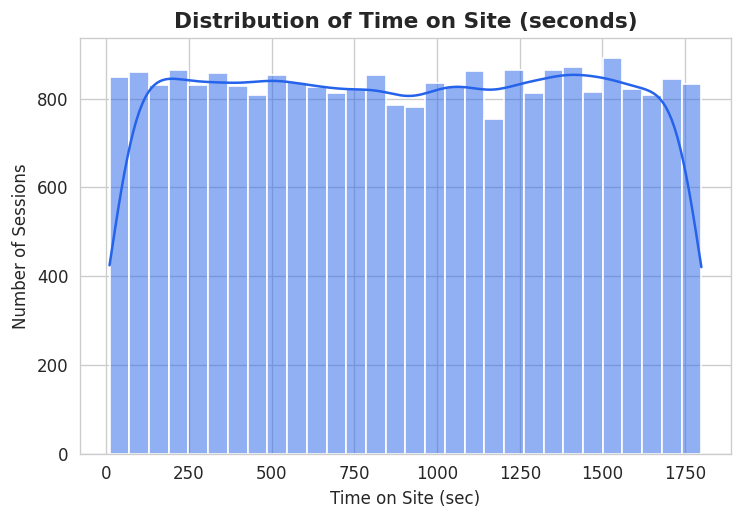

count    25000.000000
mean       903.262920
std        518.676202
min         10.000000
25%        453.000000
50%        903.000000
75%       1355.000000
max       1799.000000
Name: time_on_site_sec, dtype: float64


In [47]:
# 4.1 Univariate - distribution of time on site
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df['time_on_site_sec'], bins=30, kde=True, color='#2563eb', ax=ax)
ax.set_title('Distribution of Time on Site (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time on Site (sec)'); ax.set_ylabel('Number of Sessions')
plt.show()

print(df['time_on_site_sec'].describe())

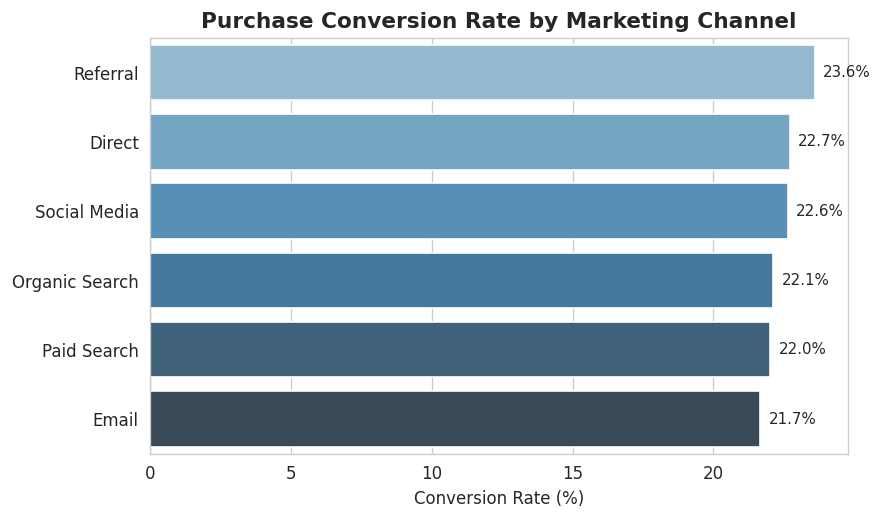

marketing_channel_lbl
Referral          23.60
Direct            22.72
Social Media      22.64
Organic Search    22.12
Paid Search       22.03
Email             21.66
Name: purchased, dtype: float64


In [48]:
# 4.2 Categorical - conversion rate by marketing channel
rate = df.groupby('marketing_channel_lbl')['purchased'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette='Blues_d', legend=False, ax=ax)
ax.set_title('Purchase Conversion Rate by Marketing Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)'); ax.set_ylabel('')
for i, v in enumerate(rate.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.show()

print(rate.round(2))

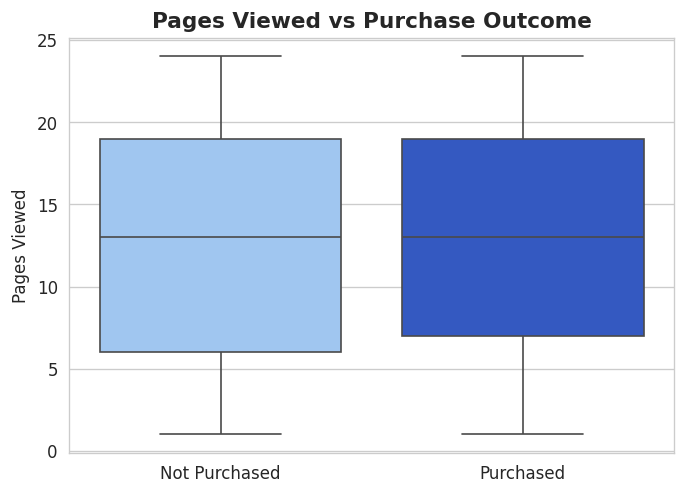

In [49]:
# 4.3 Bivariate - pages viewed vs purchase outcome
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(x='purchased', y='pages_viewed', data=df, hue='purchased',
            palette=['#93c5fd', '#1d4ed8'], legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Not Purchased', 'Purchased'])
ax.set_title('Pages Viewed vs Purchase Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Pages Viewed')
plt.show()

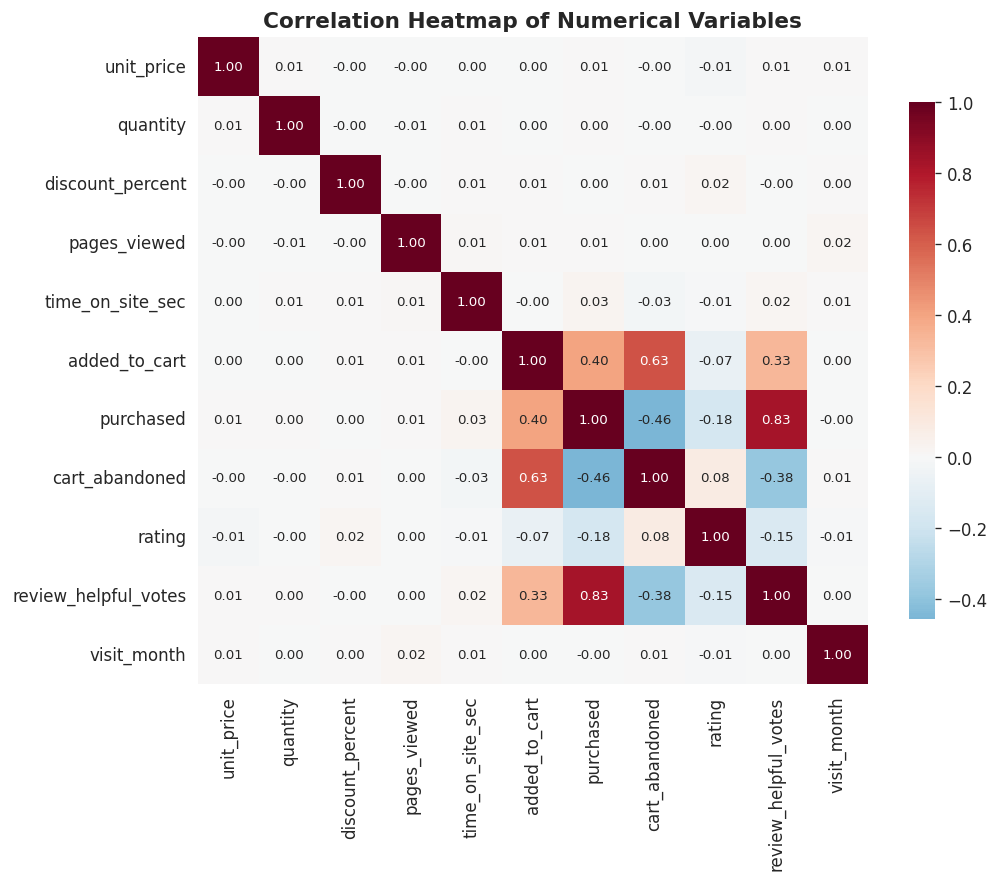

purchased               1.000
review_helpful_votes    0.831
added_to_cart           0.400
time_on_site_sec        0.027
unit_price              0.009
pages_viewed            0.006
quantity                0.004
discount_percent        0.001
visit_month            -0.004
rating                 -0.179
cart_abandoned         -0.458
Name: purchased, dtype: float64


In [50]:
# 4.4 Correlation heatmap
num_cols = ['unit_price','quantity','discount_percent','pages_viewed','time_on_site_sec',
            'added_to_cart','purchased','cart_abandoned','rating',
            'review_helpful_votes','visit_month']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap of Numerical Variables', fontsize=13, fontweight='bold')
plt.show()

# Note the high correlations for rating / review_helpful_votes / cart_abandoned --
# these are leakage artefacts, not genuine predictive signal.
print(df[num_cols].corr()['purchased'].sort_values(ascending=False).round(3))

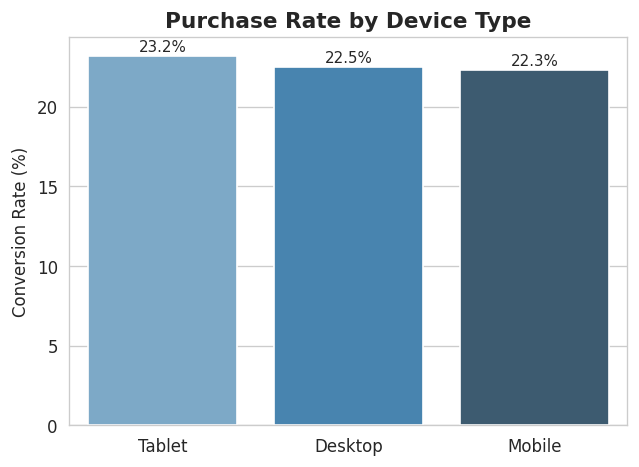

In [51]:
# 4.5 Purchase rate by device type
rate2 = df.groupby('device_type_lbl')['purchased'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.barplot(x=rate2.index, y=rate2.values, hue=rate2.index,
            palette='Blues_d', legend=False, ax=ax)
ax.set_title('Purchase Rate by Device Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Conversion Rate (%)'); ax.set_xlabel('')
for i, v in enumerate(rate2.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.show()

## 5. Statistical Analysis

In [52]:
# Descriptive statistics for key variables
key = ['unit_price','time_on_site_sec','pages_viewed','quantity','discount_percent']
desc = df[key].describe().T
desc['mode'] = df[key].mode().iloc[0]
desc[['mean','50%','mode','std','min','max']].round(2)

,mean,50%,mode,std,min,max
unit_price,782.32,691.72,343.45,476.61,50.05,1999.83
time_on_site_sec,903.26,903.00,141.00,518.68,10.00,1799.00
pages_viewed,12.54,13.00,2.00,6.93,1.00,24.00
quantity,2.49,2.00,2.00,1.11,1.00,4.00
discount_percent,9.00,10.00,0.00,9.26,0.00,30.00


In [53]:
# Chi-square test: is device type associated with purchasing?
ct = pd.crosstab(df['device_type_lbl'], df['purchased'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f'Device type      chi2={chi2:.3f}, p={p:.4f}')

# Chi-square test: is marketing channel associated with purchasing?
ct2 = pd.crosstab(df['marketing_channel_lbl'], df['purchased'])
chi2b, pb, dofb, _ = stats.chi2_contingency(ct2)
print(f'Marketing channel chi2={chi2b:.3f}, p={pb:.4f}')

print()
print('Interpretation: p > 0.05 for both -> no statistically significant association.')

Device type      chi2=0.936, p=0.6264
Marketing channel chi2=5.646, p=0.3422

Interpretation: p > 0.05 for both -> no statistically significant association.


In [54]:
# Independent t-test: do purchasers spend longer on site?
g1 = df.loc[df['purchased'] == 1, 'time_on_site_sec']
g0 = df.loc[df['purchased'] == 0, 'time_on_site_sec']
t, p_t = stats.ttest_ind(g1, g0, equal_var=False)
print(f'Time on site  -> purchasers: {g1.mean():.1f}s, non-purchasers: {g0.mean():.1f}s')
print(f'               t={t:.3f}, p={p_t:.6f}  (significant)')

print()

# Independent t-test: do purchasers view more pages?
g1b = df.loc[df['purchased'] == 1, 'pages_viewed']
g0b = df.loc[df['purchased'] == 0, 'pages_viewed']
t2, p2 = stats.ttest_ind(g1b, g0b, equal_var=False)
print(f'Pages viewed  -> purchasers: {g1b.mean():.2f}, non-purchasers: {g0b.mean():.2f}')
print(f'               t={t2:.3f}, p={p2:.4f}  (not significant)')

Time on site  -> purchasers: 929.7s, non-purchasers: 895.6s
               t=4.397, p=0.000011  (significant)

Pages viewed  -> purchasers: 12.62, non-purchasers: 12.51
               t=0.976, p=0.3291  (not significant)


## 6. Feature Engineering

In [55]:
# engagement_score combines browsing depth and duration into one measure
df['engagement_score'] = df['pages_viewed'] * df['time_on_site_sec'] / 1000

# is_weekend flags Saturday/Sunday sessions
df['is_weekend'] = df['visit_weekday'].isin([5, 6]).astype(int)

print(df.groupby('purchased')['engagement_score'].agg(['mean', 'median']).round(2))

            mean  median
purchased               
0          11.24    8.46
1          11.76    9.06


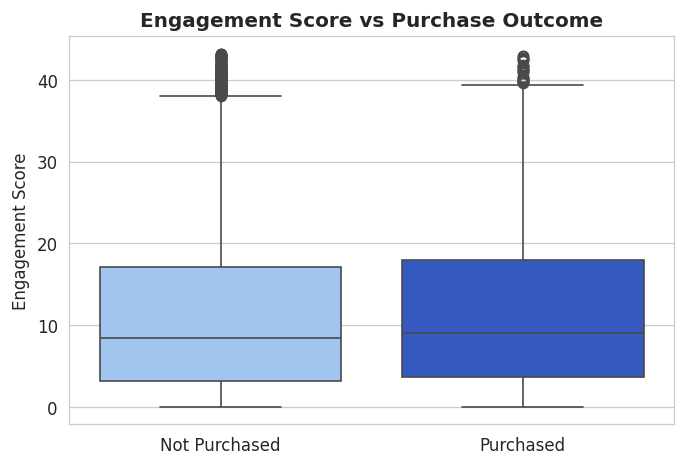

In [56]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.boxplot(x='purchased', y='engagement_score', data=df, hue='purchased',
            palette=['#93c5fd', '#1d4ed8'], legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Not Purchased', 'Purchased'])
ax.set_title('Engagement Score vs Purchase Outcome', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Engagement Score')
plt.show()

## 7. Data Preprocessing

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop leakage columns, identifiers, and the label-only helper columns
ID_COLS = ['customer_id','session_id','product_id','visit_date','location',
           'device_type_lbl','user_type_lbl','marketing_channel_lbl',
           'product_category_lbl','payment_method_lbl','visit_season_lbl',
           'session_duration_bucket']

feature_cols = [c for c in df.columns
                if c not in LEAKAGE_COLS + ID_COLS + ['purchased']]

print(f'{len(feature_cols)} features used:')
print(feature_cols)

18 features used:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'engagement_score', 'is_weekend']


In [58]:
X = df[feature_cols].copy()
y = df['purchased']

# One-hot encode the coded categorical variables
categorical = ['device_type','user_type','marketing_channel','product_category',
               'payment_method','visit_season','visit_weekday','is_weekend']
X = pd.get_dummies(X, columns=categorical, drop_first=True)

print('Shape after encoding:', X.shape)

Shape after encoding: (25000, 40)


In [59]:
# Stratified 80/20 train-test split preserves the 22.5% purchase rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Purchase rate - train: %.4f, test: %.4f' % (y_train.mean(), y_test.mean()))

Train: (20000, 40)  Test: (5000, 40)
Purchase rate - train: 0.2246, test: 0.2246


In [60]:
# Scale numeric features (needed for Logistic Regression, not for Random Forest)
num_scale = ['unit_price','quantity','discount_percent','discount_amount',
             'pages_viewed','time_on_site_sec','visit_day','visit_month',
             'engagement_score']

scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_scale] = scaler.fit_transform(X_train[num_scale])   # fit on train only
X_test_s[num_scale]  = scaler.transform(X_test[num_scale])

print('Scaling complete.')

Scaling complete.


## 8. Model Development

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             classification_report)

# class_weight='balanced' handles the 22.5% / 77.5% imbalance.
# Without it, the model just predicts "not purchased" for almost everything.

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_s, y_train)
pred_lr  = lr.predict(X_test_s)
proba_lr = lr.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
pred_rf  = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print('Both models trained.')

Both models trained.


## 9. Model Evaluation

In [62]:
def evaluate(name, model, X_tr, y_tr, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Train Acc': accuracy_score(y_tr, model.predict(X_tr)),
        'Test Acc':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', lr, X_train_s, y_train, y_test, pred_lr, proba_lr),
    evaluate('Random Forest',       rf, X_train,   y_train, y_test, pred_rf, proba_rf),
]).set_index('Model').round(4)

results

,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Logistic Regression,0.5828,0.5728,0.3444,0.9982,0.5121,0.7631
Random Forest,0.6712,0.6098,0.3557,0.9092,0.5114,0.7606


In [63]:
print('--- Logistic Regression ---')
print(classification_report(y_test, pred_lr))
print('--- Random Forest ---')
print(classification_report(y_test, pred_rf))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.45      0.62      3877
           1       0.34      1.00      0.51      1123

    accuracy                           0.57      5000
   macro avg       0.67      0.72      0.57      5000
weighted avg       0.85      0.57      0.60      5000

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      0.52      0.68      3877
           1       0.36      0.91      0.51      1123

    accuracy                           0.61      5000
   macro avg       0.65      0.72      0.59      5000
weighted avg       0.82      0.61      0.64      5000



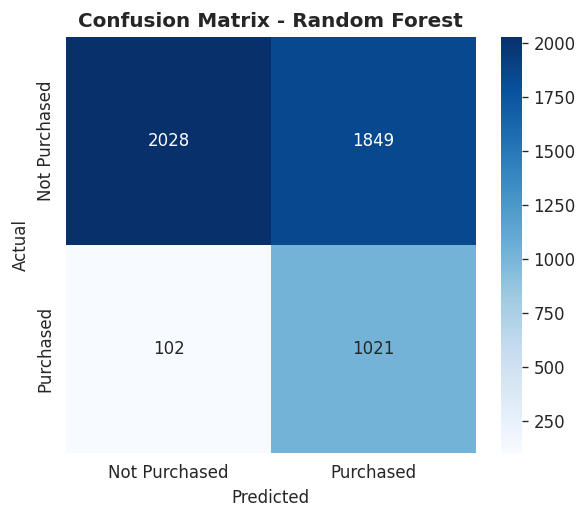

In [64]:
# Confusion matrix for the final model (Random Forest)
cm = confusion_matrix(y_test, pred_rf)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.show()

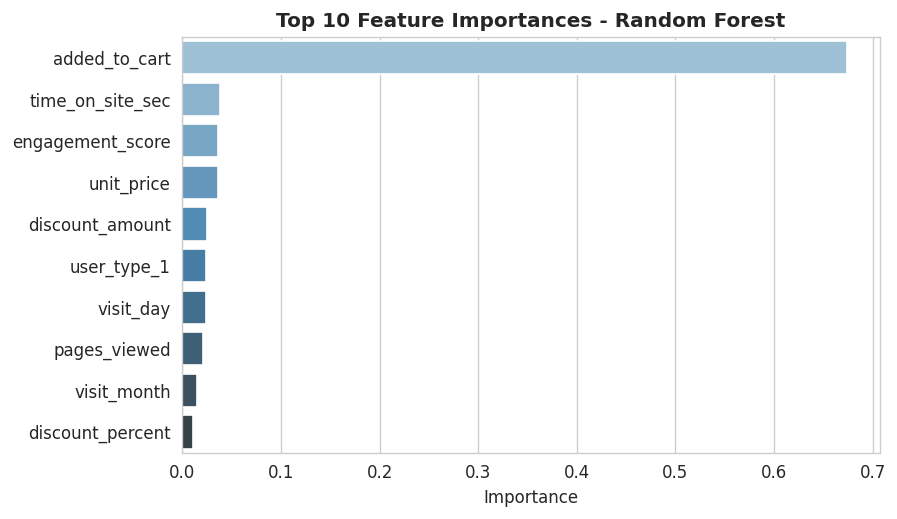

added_to_cart       0.6737
time_on_site_sec    0.0379
engagement_score    0.0361
unit_price          0.0356
discount_amount     0.0248
user_type_1         0.0240
visit_day           0.0238
pages_viewed        0.0206
visit_month         0.0151
discount_percent    0.0108
dtype: float64


In [65]:
# Feature importance
imp = pd.Series(rf.feature_importances_, index=X_train.columns)\
        .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette='Blues_d', legend=False, ax=ax)
ax.set_title('Top 10 Feature Importances - Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance'); ax.set_ylabel('')
plt.show()

print(imp.round(4))

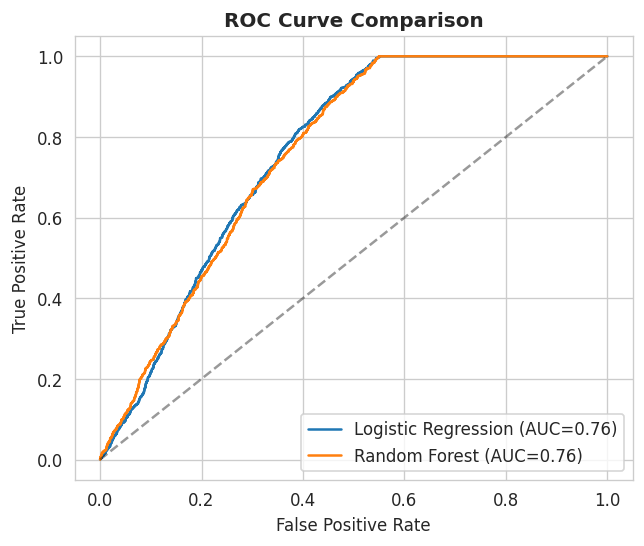

In [66]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 4.8))
for name, proba in [('Logistic Regression', proba_lr), ('Random Forest', proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax.legend()
plt.show()

## 10. Findings Summary

1. **Cart addition is the strongest behavioural predictor** — `added_to_cart` accounts for
   roughly 67% of total feature importance in the Random Forest.
2. **Device type and marketing channel do not significantly affect conversion**
   (chi-square p = 0.63 and p = 0.34 respectively).
3. **Longer time on site is weakly but significantly associated with purchasing**
   (929.7s vs 895.6s, t-test p < 0.001).
4. **Six fields were post-purchase artefacts** and had to be excluded to prevent data leakage.
5. **Final model:** Random Forest — 61% accuracy, 91% recall on purchasers, ROC-AUC 0.76.
   High recall is favoured because missing a genuine buyer costs more than an unnecessary offer.

### Recommendations
- Trigger retention interventions (exit-intent offers, cart reminders) on real-time cart
  activity and engagement score.
- Base marketing channel budget on traffic volume and cost, not assumed conversion differences.
- Always run a leakage audit as the first step in any purchase-prediction analysis.